In [ ]:
#| default_exp _utils_cam

# OpenCV for camera feed processing

> This notebook demonstrates how to set up and use OpenCV to process camera feeds in a ROS2 vision system. We will cover the basics of capturing video from a camera, displaying the feed, and performing simple image processing tasks.

## Imports

The basic packages to use OpenCV and plotting are:  

+ `cv2` for OpenCV functionality  
+ `numpy` for numerical operations (images are arrays)  
+ `matplotlib.pyplot` for plotting images and results  

The packages to use ROS2 functionality are:  

+ `rclpy` (ROS 2 Python client library)  
+ `Node` from `rclpy.node` declares the ROS2 Node superclass  
+ `ExternalShutdownException` from `rclpy.executors` to handle clean shutdowns of the ROS2 node when using OpenCV windows  
+ `CvBridge` from `cv_bridge` to convert between ROS Image messages and OpenCV images  
+ `Image` from `sensor_msgs.msg` to work with ROS Image messages  



In [ ]:
#| hide
#| export

import sys
import rclpy
from rclpy.node import Node
from rclpy.executors import ExternalShutdownException
import cv2
from cv_bridge import CvBridge
from sensor_msgs.msg import Image
import numpy as np
import matplotlib.pyplot as plt

## Functions to set the camera parameters

If you are going to connect a camera to your WSL or in general, if the bandwith is limited, it is convenient to not send the raw image but a compressed version. To set the camera to take images and send them compressed, we can use the following functions.

In [ ]:
#| export
def set_cam_format_fourcc(cam, format='MJPG'):
    "Set Pixel or Compression format"
    # Options include 'MJPG', 'YUYV', 'RGB3', etc. Check your camera documentation for supported formats.
    # Check that the format is valid, otherwise return an error message
    valid_formats = ['MJPG', 'YUYV', 'RGB3', 'GRAY', 'YUV420P', 'NV12', 'NV21']
    if format not in valid_formats:
        raise ValueError(f"Invalid format '{format}'. Valid formats are: {valid_formats}")

    # Set the camera to output raw frames (uncompressed)
    cam.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*format))

def get_cam_format_fourcc(cam):
    "Get the current Pixel or Compression format"
    codec_int = int(cam.get(cv2.CAP_PROP_FOURCC))
    codec_str = "".join([chr((codec_int >> 8 * i) & 0xFF) for i in range(4)])
    return codec_str

def set_cam_resolution(cam, width=640, height=480):
    "Set the resolution of the camera feed"
    cam.set(cv2.CAP_PROP_FRAME_WIDTH, width)
    cam.set(cv2.CAP_PROP_FRAME_HEIGHT, height)

def get_cam_resolution(cam):
    "Get the current resolution of the camera feed"
    width = int(cam.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cam.get(cv2.CAP_PROP_FRAME_HEIGHT))
    return width, height


## Connect to the camera

Test if you can take a picture with OpenCV.

In [ ]:
# source = "https://192.168.55.113:8080/video"
source = "0"  # Example of a numeric string representing a webcam index

# Convert numeric strings to int, otherwise keep as URL/path
cap = cv2.VideoCapture(int(source) if source.isdigit() else source)

[ WARN:0@59.241] global ./modules/videoio/src/cap_gstreamer.cpp (862) isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created


Check the current camera format, and set it to MJPG.

In [ ]:
print("Current camera format:", get_cam_format_fourcc(cap))
if get_cam_format_fourcc(cap) != 'MJPG':
    set_cam_format_fourcc(cap, 'MJPG')
    print("New camera format:", get_cam_format_fourcc(cap))

Current camera format: YUYV
New camera format: MJPG


Take a picture and display it.

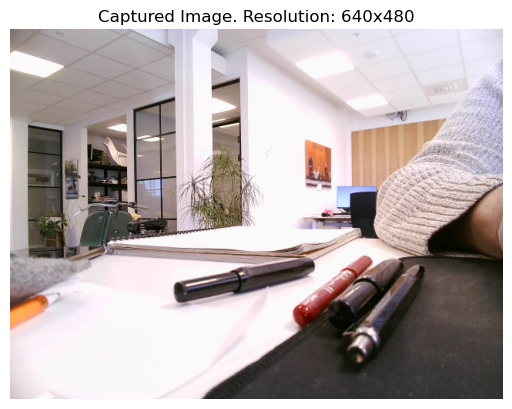

In [ ]:
ret, frame = cap.read()
if not ret:
    print("Failed to capture image")

res = (frame.shape[1], frame.shape[0])  # (width, height)

fig, ax = plt.subplots()
ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
ax.set_title(f"Captured Image. Resolution: {res[0]}x{res[1]}")
ax.axis('off')
plt.show()

We can change the resolution at which the camera captures images. Or resize the image after capturing it.
To change the camera settings for the resolution we have the function `set_cam_resolution`. To resize the image after capturing it, we can use `cv2.resize`.  

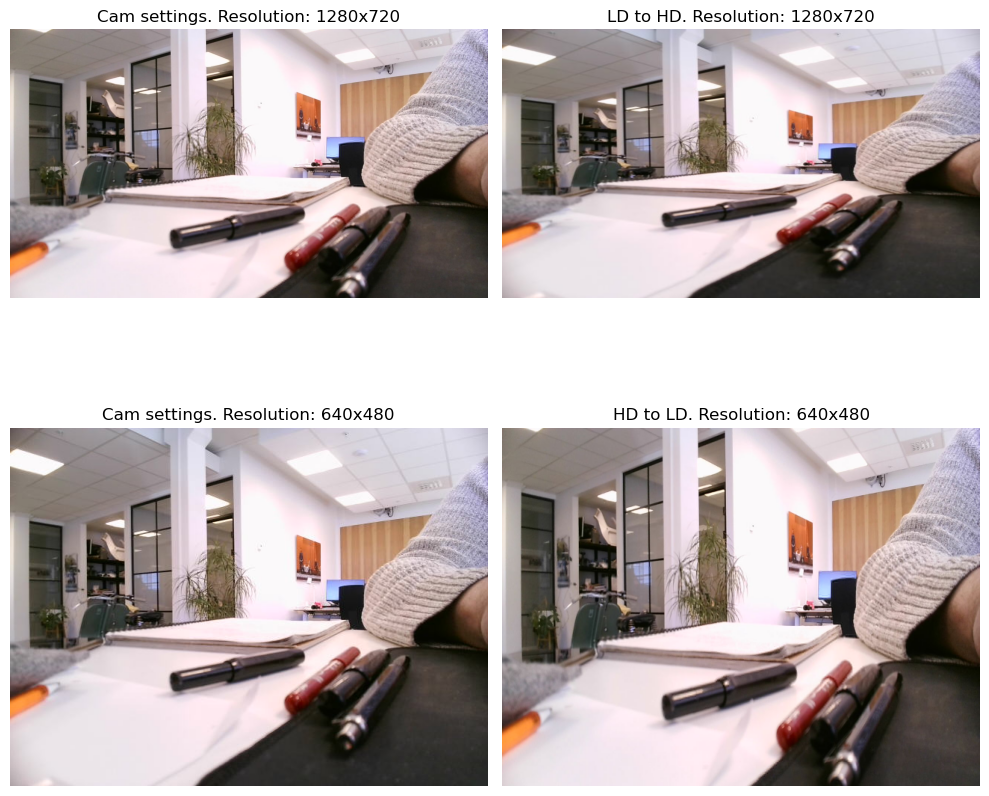

In [ ]:
HD = (1280, 720)
LD = (640, 480)

set_cam_resolution(cap, width=HD[0], height=HD[1])
ret, HDframe = cap.read()
if not ret:
    print("Failed to capture image")

set_cam_resolution(cap, width=LD[0], height=LD[1])
ret, LDframe = cap.read()
if not ret:
    print("Failed to capture image")


HDres = (HDframe.shape[1], HDframe.shape[0])  # (width, height)
LDres = (LDframe.shape[1], LDframe.shape[0])  # (width, height)

# Post-processing, reshape.
HD2LD_frame = cv2.resize(HDframe, (LD[0], LD[1]))
LD2HD_frame = cv2.resize(LDframe, (HD[0], HD[1]))

fig, ax = plt.subplots(2,2, figsize=(10, 10))
# True HD
ax[0,0].imshow(cv2.cvtColor(HDframe, cv2.COLOR_BGR2RGB))
ax[0,0].set_title(f"Cam settings. Resolution: {HDres[0]}x{HDres[1]}")
ax[0,0].axis('off')
# Reconstructed HD from LD
ax[0,1].imshow(cv2.cvtColor(LD2HD_frame, cv2.COLOR_BGR2RGB))
ax[0,1].set_title(f"LD to HD. Resolution: {HD[0]}x{HD[1]}")
ax[0,1].axis('off')
# True LD
ax[1,0].imshow(cv2.cvtColor(LDframe, cv2.COLOR_BGR2RGB))
ax[1,0].set_title(f"Cam settings. Resolution: {LDres[0]}x{LDres[1]}")
ax[1,0].axis('off')
# Downsampled HD
ax[1,1].imshow(cv2.cvtColor(HD2LD_frame, cv2.COLOR_BGR2RGB))
ax[1,1].set_title(f"HD to LD. Resolution: {LD[0]}x{LD[1]}")
ax[1,1].axis('off')

# Make axis tight
plt.tight_layout()
plt.show()



When you finish working with the camera, release it to free the resources.

In [ ]:
cap.release()

## Camera Node class

Our camera node will be a ROS2 node that captures images from the camera and publishes them as ROS2 messages. We will use parameters to be able to set the camera parameters such as:  
+ `video_source`: an integer for a connected camera or a url for a video stream.  
+ `capture_width` and `capture_height`: the resolution at which the camera captures images.  
+ `frame_rate`: the frame rate at which the camera captures images.  
+ `topic_name`: the name of the ROS2 topic where the images will be published.  
+ `video_fourcc`: the video codec to use for compression (e.g., 'MJPG' for Motion JPEG).  


Some times we can set the resolution of the camera to the desired resolution of the image, however, sometimes we will have to post-process the image, resizing it with `cv2.resize` and one of its interpolation methods. We should aim to send the smallest number of pixels possible, to save bandwidth. If the resolution needed is smaller we should resize it before sending it. 

In [ ]:
#| export
class CameraNode(Node):
    def __init__(self):
        super().__init__('camera_node')
        
        # 1. Declare the parameter with a default value (0 = default USB cam)
        # We use a string default so it can accept "0" or "http://..."
        self.declare_parameter('video_source', '0')
        self.declare_parameter('frame_rate', 30.0)
        self.declare_parameter('topic_name', '/camera/image_raw')
        self.declare_parameter('video_fourcc', 'MJPG')
        self.declare_parameter('resolution_width', 640)
        self.declare_parameter('resolution_height', 480)
        
        # 2. Get the parameter value
        self.source = self.get_parameter('video_source').value
        self.frame_rate = self.get_parameter('frame_rate').value
        self.topic_name = self.get_parameter('topic_name').value
        self.fourcc = self.get_parameter('video_fourcc').value
        self.resolution = (
            self.get_parameter('resolution_width').value,
            self.get_parameter('resolution_height').value
        )

        assert isinstance(self.source, str), "video_source parameter must be a string"
        assert isinstance(self.frame_rate, (int, float)), 'frame_rate must be a number'
        assert isinstance(self.topic_name, str), 'topic_name must be a string'
        assert isinstance(self.fourcc, str), 'FOURCC must be a string'
        assert isinstance(self.resolution, tuple) and len(self.resolution) == 2, 'resolution must be a tuple of two elements'

        # 3. Open the camera or video source
        if self.source.isdigit():
            self.cap = cv2.VideoCapture(int(self.source))
        else:
            self.cap = cv2.VideoCapture(self.source)

        if not self.cap.isOpened():
            self.get_logger().error(f"Failed to open source: {self.source}")
            raise RuntimeError('Could not open video source')

        # Publisher
        self.queueSize = 20
        self.publisher_ = self.create_publisher(Image, self.topic_name, self.queueSize)

        # Timer to publish at the desired frequency
        timer_period = 1.0 / self.frame_rate
        self.timer = self.create_timer(timer_period, self.timer_callback)

        # Set compression of the image (critical for WSL timeouts)
        set_cam_format_fourcc(self.cap, format=self.fourcc)

        # CvBridge for converting OpenCV images to ROS2 Image messages
        self.bridge = CvBridge()
        self.get_logger().info(
            f'Publ. img at {self.frame_rate} FPS, from source {self.source} on "{self.topic_name}" '
        )

        # Frame counter for logging
        self.frame_count = 0

    # Timer callback to capture and publish frames
    def timer_callback(self):
        ''' 
        Timer callback to capture and publish frames
            - Captures a frame from the camera
            - Resizes it if necessary to the specified resolution
            - Converts it to a ROS2 Image message using CvBridge
            - Publishes it on the specified topic
            - Logs the published frame count
        '''
        ret, frame = self.cap.read()
        if not ret:
            self.get_logger().warn('Failed to read frame from camera')
            return
        
        # resize the image
        if (frame.shape[1], frame.shape[0]) != self.resolution:
            frame = cv2.resize(frame, self.resolution, interpolation=cv2.INTER_CUBIC)


        # Transform the OpenCV BGR image to a ROS2 Image message
        msg = self.bridge.cv2_to_imgmsg(frame, encoding='bgr8')

        # Optional
        # msg.header.stamp = self.get_clock().now().to_msg()
        # msg.header.frame_id = 'camera_frame'
        self.publisher_.publish(msg)

        # Log
        if self.frame_count % 10 == 0:  # Log every 10 frames
            self.get_logger().info(f'Published frame {self.frame_count}')
        
        self.frame_count += 1

    def destroy_node(self):
        self.cap.release()
        super().destroy_node()
            

And the node should have a main function:

In [ ]:
#| export
def main(args=None):
    rclpy.init(args=args)
    node = CameraNode()

    try:
        rclpy.spin(node)
    except (KeyboardInterrupt, ExternalShutdownException):
        node.get_logger().info('Node stopped by user or external shutdown')
    finally:
        node.destroy_node()
        rclpy.try_shutdown()



The next cell is a trick. It allows to export the python code in the cell to the python file defined in the first cell, but since it is a Markdown cell, the notebook does not execute the code in it.  
Otherwise the node would start to publish and we would not be able to stop it without killing the kernel.  
We are exporting the block 
```python
if __name__ == '__main__':
    main()
``` 

#| hide
#| exporti

if __name__ == '__main__':
    # This allows you to run it with 'python3'
    main()

In [ ]:
#| exporti
if not hasattr(sys, 'ps1'):  # True si no estamos en el REPL (o notebook)
    if __name__=="__main__":
        main()

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()

Now the next steps for ROS2 would be to copy the node's code into a ROS2 package, create a launch file to run it, and test it with `ros2 run` or `ros2 launch`.

In [ ]:
! timeout 4s python3 ../ros2_vision_system/_utils_cam.py


[ WARN:0@1.032] global ./modules/videoio/src/cap_gstreamer.cpp (862) isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created
[INFO] [1772712810.191722456] [camera_node]: Publ. img at 30.0 FPS, from source 0 on "/camera/image_raw" 
[INFO] [1772712810.437241765] [camera_node]: Published frame 0
[INFO] [1772712810.739703839] [camera_node]: Published frame 10
[INFO] [1772712811.085715023] [camera_node]: Published frame 20
[INFO] [1772712811.403141867] [camera_node]: Published frame 30
[INFO] [1772712811.734440853] [camera_node]: Published frame 40
[INFO] [1772712812.067242007] [camera_node]: Published frame 50
[INFO] [1772712812.112470607] [camera_node]: Node stopped by user or external shutdown
Failed to publish log message to rosout: publisher's context is invalid, at ./src/rcl/publisher.c:423
